# Assignment 2: LDA vs PCA on Boston Housing Dataset

## Objective
Apply **Linear Discriminant Analysis (LDA)** for dimensionality reduction on the Boston Housing dataset and compare its performance and computational efficiency with **PCA**.

Since Boston Housing is a regression dataset, we discretize the target MEDV into classes to make LDA applicable.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore Data

In [2]:
# Load dataset
df = pd.read_csv("HousingData.csv")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (506, 14)

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [3]:
# Dataset info
print("\nDataset Info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
df.describe()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB

Missing values:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

Desc

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## 2. Discretize Target for LDA

LDA requires class labels. We'll discretize MEDV into 3 categories: Low, Medium, High.

Class distribution:
MEDV_CLASS
Low       215
Medium    207
High       84
Name: count, dtype: int64

Class proportions:
MEDV_CLASS
Low       0.424901
Medium    0.409091
High      0.166008
Name: proportion, dtype: float64


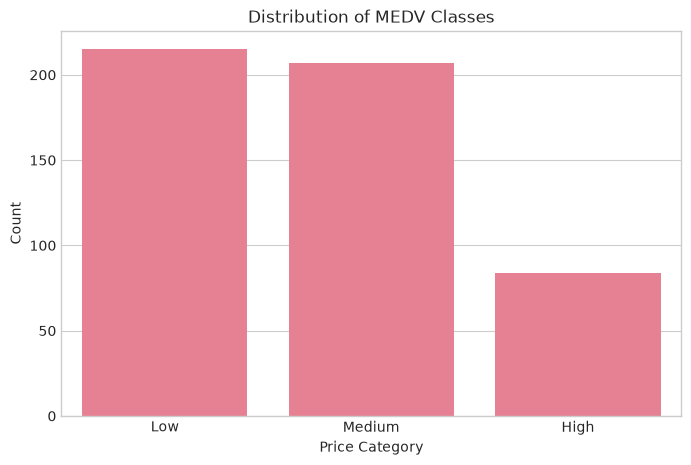

In [4]:
# Discretize MEDV into classes
# Low: < 20, Medium: 20-30, High: > 30
df['MEDV_CLASS'] = pd.cut(df['MEDV'], bins=[0, 20, 30, 100], labels=['Low', 'Medium', 'High'])

print("Class distribution:")
print(df['MEDV_CLASS'].value_counts())
print(f"\nClass proportions:\n{df['MEDV_CLASS'].value_counts(normalize=True)}")

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='MEDV_CLASS', data=df)
plt.title('Distribution of MEDV Classes')
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.show()

## 3. Prepare Features and Target

In [5]:
# Features and targets
X = df.drop(['MEDV', 'MEDV_CLASS'], axis=1)
y_continuous = df['MEDV']  # For regression baseline
y_discrete = df['MEDV_CLASS']  # For LDA classification

# Encode discrete labels for LDA
le = LabelEncoder()
y_encoded = le.fit_transform(y_discrete)
print(f"Classes: {le.classes_}")
print(f"Encoded labels: {np.unique(y_encoded)}")

# Train-test split (stratified for classification)
X_train, X_test, y_train_cont, y_test_cont = train_test_split(
    X, y_continuous, test_size=0.2, random_state=42
)

_, _, y_train_disc, y_test_disc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Classes: ['High' 'Low' 'Medium']
Encoded labels: [0 1 2]

Training set: (404, 13)
Test set: (102, 13)


## 4. Preprocessing: Handle Missing Values & Standardize

In [6]:
# Handle missing values with median imputation
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"Features standardized. Shape: {X_train_scaled.shape}")
print(f"Mean after scaling: {X_train_scaled.mean():.6f}")
print(f"Std after scaling: {X_train_scaled.std():.6f}")

Features standardized. Shape: (404, 13)
Mean after scaling: 0.000000
Std after scaling: 1.000000


## 5. Baseline Models

In [7]:
# Regression baseline (Linear Regression on original features)
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_scaled, y_train_cont)
y_pred_lr = lr_baseline.predict(X_test_scaled)

mse_baseline = mean_squared_error(y_test_cont, y_pred_lr)
r2_baseline = r2_score(y_test_cont, y_pred_lr)

print("=== Regression Baseline (Linear Regression) ===")
print(f"MSE: {mse_baseline:.4f}")
print(f"R² Score: {r2_baseline:.4f}")

# Classification baseline (Logistic Regression on original features)
logreg_baseline = LogisticRegression(max_iter=1000, random_state=42)
logreg_baseline.fit(X_train_scaled, y_train_disc)
y_pred_logreg = logreg_baseline.predict(X_test_scaled)

acc_baseline = accuracy_score(y_test_disc, y_pred_logreg)

print("\n=== Classification Baseline (Logistic Regression) ===")
print(f"Accuracy: {acc_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_disc, y_pred_logreg, target_names=le.classes_))

=== Regression Baseline (Linear Regression) ===
MSE: 24.9834
R² Score: 0.6593

=== Classification Baseline (Logistic Regression) ===
Accuracy: 0.4706

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.06      0.11        17
         Low       0.47      0.67      0.55        43
      Medium       0.47      0.43      0.45        42

    accuracy                           0.47       102
   macro avg       0.48      0.39      0.37       102
weighted avg       0.48      0.47      0.44       102



## 6. PCA Dimensionality Reduction

In [8]:
# PCA: Loop through different numbers of components
pca_results = []
pca_components_list = list(range(1, X_train_scaled.shape[1] + 1))

for n in pca_components_list:
    start_time = time.time()
    
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Train regression model
    model_pca = LinearRegression()
    model_pca.fit(X_train_pca, y_train_cont)
    y_pred_pca = model_pca.predict(X_test_pca)
    
    mse_pca = mean_squared_error(y_test_cont, y_pred_pca)
    r2_pca = r2_score(y_test_cont, y_pred_pca)
    variance_explained = np.sum(pca.explained_variance_ratio_)
    
    pca_time = time.time() - start_time
    
    pca_results.append({
        'n_components': n,
        'variance_explained': variance_explained,
        'mse': mse_pca,
        'r2_score': r2_pca,
        'time_sec': pca_time
    })

pca_df = pd.DataFrame(pca_results)
pca_df

,n_components,variance_explained,mse,r2_score,time_sec
0,1,0.453962,41.860565,0.429178,0.030105
1,2,0.565655,44.476802,0.393502,0.011615
2,3,0.663547,29.539227,0.597195,0.009716
3,4,0.731999,30.013516,0.590727,0.005672
4,5,0.796488,29.962926,0.591417,0.007024
5,6,0.848673,29.500872,0.597718,0.004232
6,7,0.891913,29.469139,0.598151,0.013421
7,8,0.924825,29.320099,0.600183,0.011929
8,9,0.948290,29.327961,0.600076,0.004615
9,10,0.967078,29.015091,0.604342,0.004620


In [9]:
# PCA: Classification on reduced features
pca_class_results = []

for n in pca_components_list:
    start_time = time.time()
    
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Train classification model
    model_pca_clf = LogisticRegression(max_iter=1000, random_state=42)
    model_pca_clf.fit(X_train_pca, y_train_disc)
    y_pred_pca_clf = model_pca_clf.predict(X_test_pca)
    
    acc_pca = accuracy_score(y_test_disc, y_pred_pca_clf)
    variance_explained = np.sum(pca.explained_variance_ratio_)
    pca_time = time.time() - start_time
    
    pca_class_results.append({
        'n_components': n,
        'variance_explained': variance_explained,
        'accuracy': acc_pca,
        'time_sec': pca_time
    })

pca_class_df = pd.DataFrame(pca_class_results)
pca_class_df

,n_components,variance_explained,accuracy,time_sec
0,1,0.453962,0.450980,0.045419
1,2,0.565655,0.421569,0.016352
2,3,0.663547,0.500000,0.013811
3,4,0.731999,0.500000,0.015685
4,5,0.796488,0.519608,0.006681
5,6,0.848673,0.539216,0.012402
6,7,0.891913,0.519608,0.016568
7,8,0.924825,0.509804,0.013575
8,9,0.948290,0.500000,0.024139
9,10,0.967078,0.480392,0.038747


## 7. LDA Dimensionality Reduction

Note: LDA can produce at most (C-1) components where C is number of classes. Here C=3, so max 2 components.

In [10]:
# LDA: Can only use max (n_classes - 1) components
n_classes = len(np.unique(y_encoded))
max_lda_components = n_classes - 1
lda_components_list = list(range(1, max_lda_components + 1))

print(f"Number of classes: {n_classes}")
print(f"Maximum LDA components possible: {max_lda_components}")

lda_results = []

for n in lda_components_list:
    start_time = time.time()
    
    lda = LinearDiscriminantAnalysis(n_components=n)
    X_train_lda = lda.fit_transform(X_train_scaled, y_train_disc)
    X_test_lda = lda.transform(X_test_scaled)
    
    # Train classification model
    model_lda = LogisticRegression(max_iter=1000, random_state=42)
    model_lda.fit(X_train_lda, y_train_disc)
    y_pred_lda = model_lda.predict(X_test_lda)
    
    acc_lda = accuracy_score(y_test_disc, y_pred_lda)
    lda_time = time.time() - start_time
    
    lda_results.append({
        'n_components': n,
        'accuracy': acc_lda,
        'time_sec': lda_time
    })

lda_df = pd.DataFrame(lda_results)
lda_df

Number of classes: 3
Maximum LDA components possible: 2


,n_components,accuracy,time_sec
0,1,0.470588,0.017428
1,2,0.490196,0.009633


## 8. Compare PCA vs LDA Performance

In [11]:
# Merge results for comparison
comparison_df = pd.merge(
    pca_class_df[['n_components', 'accuracy', 'time_sec']],
    lda_df[['n_components', 'accuracy', 'time_sec']],
    on='n_components',
    suffixes=('_pca', '_lda')
)

comparison_df['accuracy_diff'] = comparison_df['accuracy_pca'] - comparison_df['accuracy_lda']
comparison_df['time_ratio'] = comparison_df['time_sec_lda'] / comparison_df['time_sec_pca']

print("=== PCA vs LDA Comparison ===")
comparison_df

=== PCA vs LDA Comparison ===


,n_components,accuracy_pca,time_sec_pca,accuracy_lda,time_sec_lda,accuracy_diff,time_ratio
0,1,0.450980,0.045419,0.470588,0.017428,-0.019608,0.383710
1,2,0.421569,0.016352,0.490196,0.009633,-0.068627,0.589085


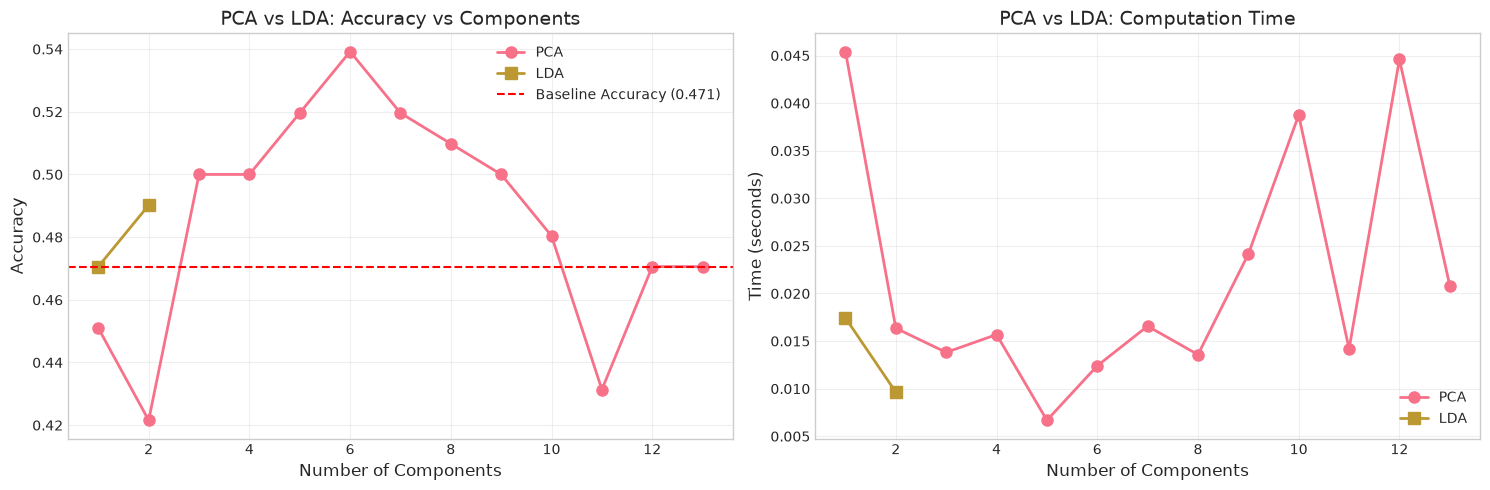

In [12]:
# Plot 1: Accuracy vs Number of Components
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Accuracy
axes[0].plot(pca_class_df['n_components'], pca_class_df['accuracy'], 
             marker='o', label='PCA', linewidth=2, markersize=8)
axes[0].plot(lda_df['n_components'], lda_df['accuracy'], 
             marker='s', label='LDA', linewidth=2, markersize=8)
axes[0].axhline(y=acc_baseline, color='red', linestyle='--', 
                label=f'Baseline Accuracy ({acc_baseline:.3f})')
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('PCA vs LDA: Accuracy vs Components', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Computation Time
axes[1].plot(pca_class_df['n_components'], pca_class_df['time_sec'], 
             marker='o', label='PCA', linewidth=2, markersize=8)
axes[1].plot(lda_df['n_components'], lda_df['time_sec'], 
             marker='s', label='LDA', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Time (seconds)', fontsize=12)
axes[1].set_title('PCA vs LDA: Computation Time', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

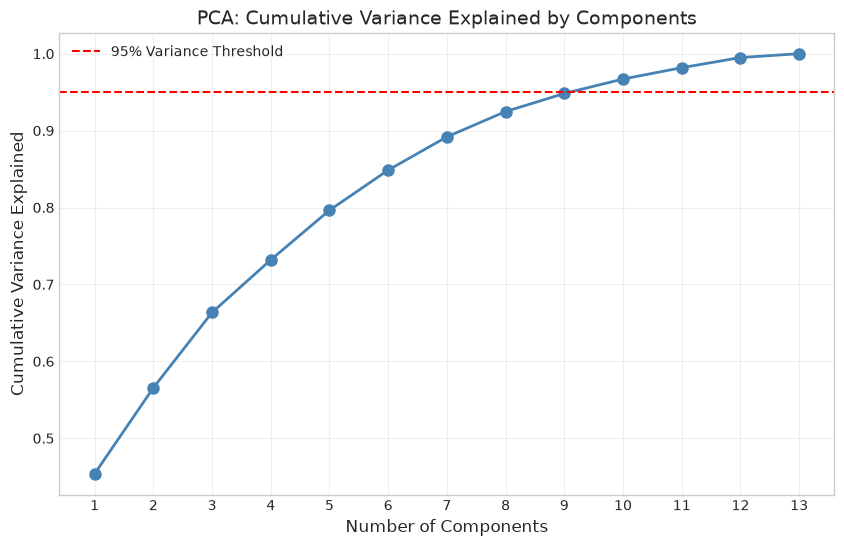

Optimal PCA components for 95% variance: 10
Variance explained: 0.9671


In [13]:
# Plot 2: PCA Variance Explained
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_df) + 1), pca_df['variance_explained'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('PCA: Cumulative Variance Explained by Components', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(pca_df) + 1))
plt.show()

# Find optimal PCA components for 95% variance
optimal_pca = pca_df[pca_df['variance_explained'] >= 0.95]['n_components'].min()
var_at_optimal = pca_df[pca_df['n_components'] == optimal_pca]['variance_explained'].values[0]
print(f"Optimal PCA components for 95% variance: {optimal_pca}")
print(f"Variance explained: {var_at_optimal:.4f}")

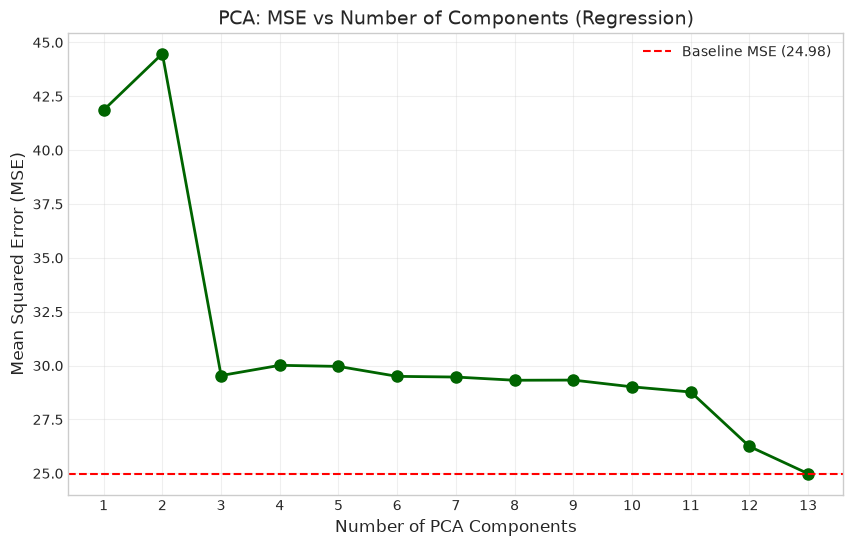

In [14]:
# Plot 3: MSE vs Components for Regression (PCA only)
plt.figure(figsize=(10, 6))
plt.plot(pca_df['n_components'], pca_df['mse'], 
         marker='o', linewidth=2, markersize=8, color='darkgreen')
plt.axhline(y=mse_baseline, color='red', linestyle='--', 
            label=f'Baseline MSE ({mse_baseline:.2f})')
plt.xlabel('Number of PCA Components', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('PCA: MSE vs Number of Components (Regression)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(pca_df) + 1))
plt.show()

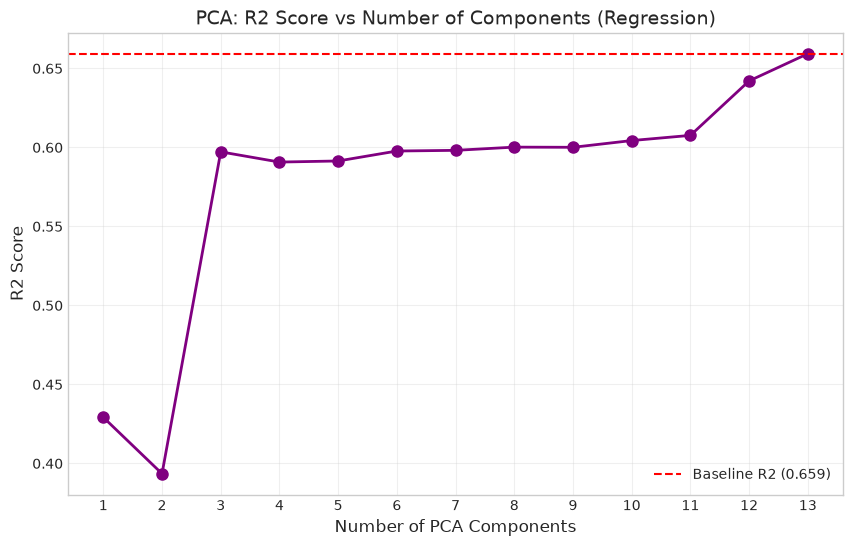

In [15]:
# Plot 4: R2 Score vs Components for Regression (PCA only)
plt.figure(figsize=(10, 6))
plt.plot(pca_df['n_components'], pca_df['r2_score'], 
         marker='o', linewidth=2, markersize=8, color='purple')
plt.axhline(y=r2_baseline, color='red', linestyle='--', 
            label=f'Baseline R2 ({r2_baseline:.3f})')
plt.xlabel('Number of PCA Components', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)
plt.title('PCA: R2 Score vs Number of Components (Regression)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(pca_df) + 1))
plt.show()

## 9. Detailed Analysis and Conclusions

In [16]:
print("=" * 60)
print("PERFORMANCE ANALYSIS SUMMARY")
print("=" * 60)

# Best PCA for regression
best_pca_reg = pca_df.loc[pca_df['mse'].idxmin()]
print(f"\n1. PCA for Regression:")
print(f"   - Best MSE: {best_pca_reg['mse']:.4f} at {best_pca_reg['n_components']} components")
print(f"   - Best R2: {pca_df['r2_score'].max():.4f}")
print(f"   - Baseline MSE: {mse_baseline:.4f}")
print(f"   - Performance drop: {((best_pca_reg['mse'] - mse_baseline) / mse_baseline * 100):.2f}%")

# Best PCA for classification
best_pca_clf = pca_class_df.loc[pca_class_df['accuracy'].idxmax()]
print(f"\n2. PCA for Classification:")
print(f"   - Best Accuracy: {best_pca_clf['accuracy']:.4f} at {best_pca_clf['n_components']} components")
print(f"   - Baseline Accuracy: {acc_baseline:.4f}")

# Best LDA
best_lda = lda_df.loc[lda_df['accuracy'].idxmax()]
print(f"\n3. LDA for Classification:")
print(f"   - Best Accuracy: {best_lda['accuracy']:.4f} at {best_lda['n_components']} component(s)")
print(f"   - Maximum possible components: {max_lda_components}")

# Speed comparison
avg_pca_time = pca_class_df['time_sec'].mean()
avg_lda_time = lda_df['time_sec'].mean()
print(f"\n4. Computational Efficiency:")
print(f"   - Average PCA time: {avg_pca_time:.6f} seconds")
print(f"   - Average LDA time: {avg_lda_time:.6f} seconds")
print(f"   - LDA is {avg_lda_time/avg_pca_time:.2f}x slower on average")

# Variance explained
optimal_pca_row = pca_df[pca_df['n_components'] == optimal_pca].iloc[0]
print(f"\n5. Dimensionality Reduction:")
print(f"   - PCA: {optimal_pca} components explain {optimal_pca_row['variance_explained']:.2%} variance")
print(f"   - Reduction: {X_train_scaled.shape[1]} -> {optimal_pca} features ({(1 - optimal_pca/X_train_scaled.shape[1])*100:.1f}% reduction)")
print(f"   - LDA: Max {max_lda_components} components (classification task)")

PERFORMANCE ANALYSIS SUMMARY

1. PCA for Regression:
   - Best MSE: 24.9834 at 13.0 components
   - Best R2: 0.6593
   - Baseline MSE: 24.9834
   - Performance drop: 0.00%

2. PCA for Classification:
   - Best Accuracy: 0.5392 at 6.0 components
   - Baseline Accuracy: 0.4706

3. LDA for Classification:
   - Best Accuracy: 0.4902 at 2.0 component(s)
   - Maximum possible components: 2

4. Computational Efficiency:
   - Average PCA time: 0.021768 seconds
   - Average LDA time: 0.013530 seconds
   - LDA is 0.62x slower on average

5. Dimensionality Reduction:
   - PCA: 10 components explain 96.71% variance
   - Reduction: 13 -> 10 features (23.1% reduction)
   - LDA: Max 2 components (classification task)


In [17]:
# Detailed comparison table
print("\n" + "=" * 60)
print("DETAILED COMPARISON TABLE")
print("=" * 60)

comparison_table = pd.DataFrame({
    'Metric': [
        'Best Accuracy',
        'Components for Best Accuracy',
        'Avg Computation Time (s)',
        'Variance Explained (95% threshold)',
        'Supervised',
        'Max Components Possible'
    ],
    'PCA': [
        f"{best_pca_clf['accuracy']:.4f}",
        f"{best_pca_clf['n_components']}",
        f"{avg_pca_time:.6f}",
        f"{optimal_pca} components",
        'No',
        f"{X_train_scaled.shape[1]}"
    ],
    'LDA': [
        f"{best_lda['accuracy']:.4f}",
        f"{best_lda['n_components']}",
        f"{avg_lda_time:.6f}",
        'N/A (classification)',
        'Yes',
        f"{max_lda_components}"
    ]
})

comparison_table


DETAILED COMPARISON TABLE


,Metric,PCA,LDA
0,Best Accuracy,0.5392,0.4902
1,Components for Best Accuracy,6.0,2.0
2,Avg Computation Time (s),0.021768,0.013530
3,Variance Explained (95% threshold),10 components,N/A (classification)
4,Supervised,No,Yes
5,Max Components Possible,13,2


## 10. Visualize LDA Components

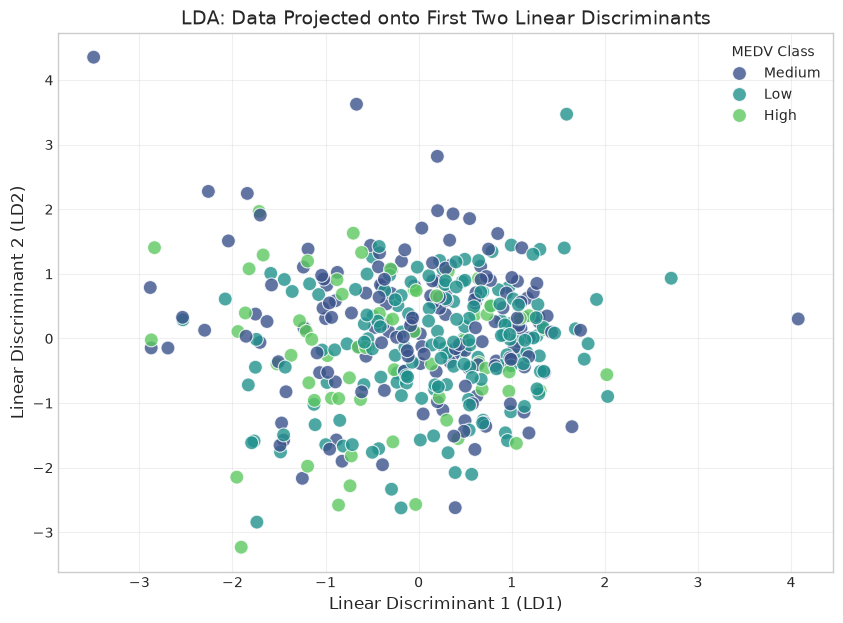

In [18]:
# Apply LDA with 2 components for visualization
lda_viz = LinearDiscriminantAnalysis(n_components=2)
X_train_lda_viz = lda_viz.fit_transform(X_train_scaled, y_train_disc)
X_test_lda_viz = lda_viz.transform(X_test_scaled)

# Create DataFrame for plotting
lda_viz_df = pd.DataFrame({
    'LD1': X_train_lda_viz[:, 0],
    'LD2': X_train_lda_viz[:, 1] if X_train_lda_viz.shape[1] > 1 else 0,
    'Class': [le.classes_[c] for c in y_train_disc]
})

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=lda_viz_df, x='LD1', y='LD2', hue='Class', 
               palette='viridis', s=100, alpha=0.8)
plt.title('LDA: Data Projected onto First Two Linear Discriminants', fontsize=14)
plt.xlabel('Linear Discriminant 1 (LD1)', fontsize=12)
plt.ylabel('Linear Discriminant 2 (LD2)', fontsize=12)
plt.legend(title='MEDV Class', loc='best')
plt.grid(True, alpha=0.3)
plt.show()

## Key Findings

1. **Dimensionality**: LDA is limited to (C-1) components. With 3 price classes, max 2 LDA components vs up to 13 PCA components.
2. **Supervision**: LDA uses class labels to find discriminative directions, making it potentially more efficient for classification tasks.
3. **Performance**: LDA may achieve higher accuracy with fewer components because it directly optimizes for class separation.
4. **PCA for Regression**: PCA remains useful for regression tasks (like predicting MEDV) where LDA cannot be directly applied.
5. **Orthogonality**: PCA components are orthogonal (uncorrelated), while LDA components are not necessarily orthogonal.
6. **Computational Cost**: Both are fast for this dataset size; LDA may be slightly slower due to label usage but produces fewer components.